## 1. Local PC Setup

This notebook is designed to run from your PC using Jupyter Notebook, JupyterLab, or VS Code.

Before running:

1. Extract the dataset archives.
2. Place the notebook in the same folder as `train` and `trainLabels.csv` file.
3. Run the cells from top to bottom.

The notebook uses:

```python
BASE_DIR = Path.cwd()
```

This means the current notebook folder is treated as the dataset folder.


# CIFAR-10 Image Classification: PyTorch and TensorFlow

This PC/local notebook implements and compares:

1. PyTorch Simple Neural Network
2. PyTorch CNN
3. TensorFlow Simple Neural Network
4. TensorFlow CNN

## Expected Folder Structure

Save this notebook in the same folder that contains the extracted dataset folders and CSV files:

```text
Project_Folder/
├── CIFAR10_PyTorch_then_TensorFlow_PC_Local.ipynb
├── trainLabels.csv
├── train/
    ├── 1.png
    ├── 2.png
    └── ...

```

No archive extraction is performed. The `train` and `test` folders must already be extracted.


Importing the required libraries and initialising the following variables (also checking if they exist):

1. BASE_DIR variable
2. TRAIN_DIR variable
3. LABELS_FILE variable

In [17]:
# Importing the libraries required.
import time
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


# Use the folder where the notebook is located
BASE_DIR = Path.cwd()

TRAIN_DIR = BASE_DIR / "train"
TEST_DIR = BASE_DIR / "test"
LABELS_FILE = BASE_DIR / "trainLabels.csv"

# Displaying the paths to the working directory, train folder and the labels file
print("Working Directory:", BASE_DIR)
print("Train Folder:", TRAIN_DIR)
#print("Test Folder:", TEST_DIR)
print("Labels File:", LABELS_FILE)

#checking if the TRAIN Folder containing the 50,000 images exists and whether the labels file exists as well
assert TRAIN_DIR.exists(), f"Training folder not found: {TRAIN_DIR}"
#assert TEST_DIR.exists(), f"Test folder not found: {TEST_DIR}"
assert LABELS_FILE.exists(), f"Labels file not found: {LABELS_FILE}"


Working Directory: D:\02.OUK\Deep Learning Assignments\01.Module 2\01.Pytorch
Train Folder: D:\02.OUK\Deep Learning Assignments\01.Module 2\01.Pytorch\train
Labels File: D:\02.OUK\Deep Learning Assignments\01.Module 2\01.Pytorch\trainLabels.csv


## 2. Load and Prepare Dataset

*   Checking that the training folder and that the trainLabels.csv are available
*   Verifying that every image referenced in trainLabels.csv actually exists in the training image folder before model training begins


In [18]:
# Load labels
labels_df = pd.read_csv(LABELS_FILE)

# Build full image paths
labels_df["filepath"] = labels_df["id"].apply(
    lambda x: TRAIN_DIR / f"{x}.png"
)

# Check for missing images
missing = labels_df[~labels_df["filepath"].apply(lambda p: p.exists())]

# Printing out the numbers of the total number of images and the number of missing training images
print("Total labelled images:", len(labels_df))
print("Missing training images:", len(missing))

# Printing out the names of the missing files
if len(missing) > 0:
    print("\nExamples of missing files:")
    display(missing.head())
    raise FileNotFoundError(
        f"{len(missing)} training images are missing."
    )

print("All training images found successfully.")

Total labelled images: 50000
Missing training images: 0
All training images found successfully.


In [19]:
# Performing label encoding and splitting the dataset into training and validation sets before training the neural network.
label_encoder = LabelEncoder()
labels_df["label_encoded"] = label_encoder.fit_transform(labels_df["label"])

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

# Splitting labelled data into training and validation subsets
train_df, val_df = train_test_split(
    labels_df,
    test_size=0.2, # use 20% of the data for validation
    random_state=42, # Ensure the split is reproducible
    stratify=labels_df["label_encoded"]
)

# Displaying the classes, number of classes, number of training records and number of validation records.
print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Training records:", len(train_df))
print("Validation records:", len(val_df))


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of classes: 10
Training records: 40000
Validation records: 10000


In [20]:
# Setting the batch size (Images to be processed at a time resulting in 625 batches i.e. 40,000/64) and epochs configuration (Number of times the 40,000 images are processed)
BATCH_SIZE = 64
EPOCHS = 5

# Results storage structure
comparison_results = []


# Part A: PyTorch Implementation

In [21]:
# Importing the torch, neural network and optimisation libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Checking the PyTorch version installed
print("PyTorch version:", torch.__version__)

# Using GPU where it is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


PyTorch version: 2.11.0+cu128
Using device: cuda


In [22]:
""" This class creates a custom PyTorch dataset that determines PyTorch how to load CIFAR-10 images
    and their labels from the dataframe.
    It acts as a bridge between your CSV file and the neural network.
"""

class CIFAR10ImageDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    #Returns the size of the training dataset
    def __len__(self):
        return len(self.df)

    #Gets an image.
    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["filepath"]).convert("RGB") # Loading the image from disk
        image = np.asarray(image, dtype=np.float32) / 255.0 # Converting the image to NumPy array
        image = np.transpose(image, (2, 0, 1))  # HWC to CHW. Normalizing pixel values and reordering dimensions

        label = int(row["label_encoded"]) # Getting the label

        return torch.tensor(image, dtype=torch.float32), torch.tensor(label, dtype=torch.long) #Returning the tensors

# Creating the training and validation dataset
train_dataset = CIFAR10ImageDataset(train_df)
val_dataset = CIFAR10ImageDataset(val_df)

# Creating the training DataLoader to feed images to the model in batches.
# shuffle=True randomizes the order of samples during training.
# num_workers=0 is safest when running Jupyter on Windows
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

#Displaying the number of training and validation batches
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))


Training batches: 625
Validation batches: 157


In [23]:
"""
    This function performs one complete training epoch for the neural network.
    An epoch means the model sees every image in the training dataset once.
"""
def train_one_epoch(model, loader, criterion, optimizer):
    model.train() # Putting the model in training mode.
    running_loss = 0.0 # Variable to track total loss
    correct = 0 # Variable to track number of images classified correctly
    total = 0 # Variable to track total number of images processed

    # Looping through each batch.
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad() # Clearing old gradients from the previous batch
        outputs = model(images) # Forward pass: generate predictions.
        loss = criterion(outputs, labels)  # Calculating prediction error.

        loss.backward()  # Backward pass: calculating gradients
        optimizer.step() # Updating model weights using the optimizer.

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item() # Counting the correct predictions
        total += labels.size(0) # Counting total processed labels.

    return running_loss / total, correct / total # Returning the average loss and accuracy for this epoch.

# Function to evaluate a PyTorch model without updating its weights.
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    # Disabling gradient tracking because validation does not require backpropagation.
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images) # Forward pass only
            loss = criterion(outputs, labels) # Calculating the validation loss

            running_loss += loss.item() * images.size(0) # Accumulating validation loss
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item() # Counting the correct predictions
            total += labels.size(0) # Counting the total validation samples

    return running_loss / total, correct / total

# Function for training a PyTorch model across all epochs and record results.
def run_pytorch_training(model, model_name):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    history = []
    start = time.perf_counter()

    # Running training and validation for each epoch
    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        #Saving the epoch metrics
        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc
        })

        # Displaying progress for the Epoch
        print(
            f"{model_name} | Epoch {epoch + 1}/{EPOCHS} | "
            f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}"
        )

    training_time = time.perf_counter() - start # Calculating total training time
    final_accuracy = history[-1]["val_acc"]

    comparison_results.append({
        "Framework": "PyTorch",
        "Model": model_name,
        "Training Time Seconds": training_time,
        "Validation Accuracy": final_accuracy
    })

    return model, pd.DataFrame(history), training_time, final_accuracy


## PyTorch Simple Neural Network

In [24]:
"""
    Defining a simple fully connected neural network in PyTorch.
"""
class PyTorchSimpleNN(nn.Module):
    # Initializing the network layers
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(), # Flattening 32x32x3 image into a 3,072-value vector.
            nn.Linear(32 * 32 * 3, 256), # First dense layer
            nn.ReLU(), # ReLU activation adds non-linearity.
            nn.Linear(256, 128),  # Second dense layer.
            nn.ReLU(), # Second ReLU activation.
            nn.Linear(128, num_classes) # Output layer with one score for each class.
        )

    #Defining the forward pass
    def forward(self, x):
        return self.net(x)

# Training the PyTorch Simple Neural Network
pytorch_simple_model, pytorch_simple_history, pytorch_simple_time, pytorch_simple_acc = run_pytorch_training(
    PyTorchSimpleNN(),
    "Simple Neural Network"
)

# Displaying training time and validation accuracy
print(f"PyTorch Simple NN training time: {pytorch_simple_time:.2f} seconds")
print(f"PyTorch Simple NN validation accuracy: {pytorch_simple_acc:.4f}")


Simple Neural Network | Epoch 1/5 | Train Acc: 0.3189 | Val Acc: 0.3702
Simple Neural Network | Epoch 2/5 | Train Acc: 0.3861 | Val Acc: 0.4212
Simple Neural Network | Epoch 3/5 | Train Acc: 0.4208 | Val Acc: 0.4454
Simple Neural Network | Epoch 4/5 | Train Acc: 0.4435 | Val Acc: 0.4477
Simple Neural Network | Epoch 5/5 | Train Acc: 0.4623 | Val Acc: 0.4345
PyTorch Simple NN training time: 747.85 seconds
PyTorch Simple NN validation accuracy: 0.4345


## PyTorch CNN

In [25]:
"""
    Defining a Convolutional Neural Network in PyTorch
"""
class PyTorchCNN(nn.Module):
    # Initializing the CNN Layers.
    def __init__(self):
        super().__init__()

        # Feature extraction section learns visual patterns from images.
        self.features = nn.Sequential(
            
            # First convolution layer: 3 input channels to 32 feature maps.
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # Reducing image size from 32x32 to 16x16.

            # Second convolution layer: 32 to 64 feature maps.
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # Reduce image size from 16x16 to 8x8.

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        # Classifier section converts extracted features into class scores.
        self.classifier = nn.Sequential(
            nn.Flatten(), # Flatten feature maps into a vector.
            
            # Dense layer for classification.
            nn.Linear(128 * 4 * 4, 128), 
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes) # Output layer with one score for each class.
        )

    # Defining the forward pass.
    def forward(self, x):
        x = self.features(x) # Extract image features
        return self.classifier(x) # Classify extracted features

# Training the PyTorch CNN
pytorch_cnn_model, pytorch_cnn_history, pytorch_cnn_time, pytorch_cnn_acc = run_pytorch_training(PyTorchCNN(),"CNN")

# Displaying the training time and validatio accuracy
print(f"PyTorch CNN training time: {pytorch_cnn_time:.2f} seconds")
print(f"PyTorch CNN validation accuracy: {pytorch_cnn_acc:.4f}")


CNN | Epoch 1/5 | Train Acc: 0.3876 | Val Acc: 0.5190
CNN | Epoch 2/5 | Train Acc: 0.5296 | Val Acc: 0.5926
CNN | Epoch 3/5 | Train Acc: 0.5983 | Val Acc: 0.6373
CNN | Epoch 4/5 | Train Acc: 0.6398 | Val Acc: 0.6814
CNN | Epoch 5/5 | Train Acc: 0.6779 | Val Acc: 0.6658
PyTorch CNN training time: 345.53 seconds
PyTorch CNN validation accuracy: 0.6658


# Part B: TensorFlow Implementation

In [26]:
# Importing TensorFlow for the TensorFlow/Keras implementation.
import tensorflow as tf

# Displaying TensorFlow version and GPU devices detected by TensorFlow if any
print("TensorFlow version:", tf.__version__)
print("TensorFlow GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.20.0
TensorFlow GPU devices: []


In [27]:
# CIFAR Images are 32 X 32 pixels
IMG_SIZE = (32, 32)

# Load and preprocess one image for TensorFlow.
def load_image_tf(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Create a TensorFlow dataset from a dataframe.
def make_tf_dataset(df, shuffle=True):
    paths = df["filepath"].astype(str).values
    labels = df["label_encoded"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image_tf, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=5000)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

# Create TensorFlow training dataset.
tf_train_ds = make_tf_dataset(train_df, shuffle=True)

# Create TensorFlow validation dataset.
tf_val_ds = make_tf_dataset(val_df, shuffle=False)


## TensorFlow Simple Neural Network

In [28]:
# Build a simple fully connected neural network in TensorFlow/Keras.
def build_tensorflow_simple_nn():
    # Creating a sequential model.
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),# Define input image shape.
        tf.keras.layers.Flatten(), # Flattening image into one vector.
        tf.keras.layers.Dense(256, activation="relu"), # First dense hidden layer.
        tf.keras.layers.Dense(128, activation="relu"), # Second dense hidden laye
        tf.keras.layers.Dense(num_classes, activation="softmax") # Output layer with class probabilities
    ])

    # Compiling the model with optimizer, loss, and accuracy metric
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Creating TensorFlow simple neural network
tf_simple_model = build_tensorflow_simple_nn()
tf_simple_model.summary() # Displaying model architecture

# Start timing model training
start = time.perf_counter()

# Training the model
tf_simple_history = tf_simple_model.fit(
    tf_train_ds,
    validation_data=tf_val_ds,
    epochs=EPOCHS
)

#Calculating the total training time
tf_simple_time = time.perf_counter() - start

# Evaluating the model on validation data
tf_simple_loss, tf_simple_acc = tf_simple_model.evaluate(tf_val_ds, verbose=0)

# Storing results for final comparison
comparison_results.append({
    "Framework": "TensorFlow",
    "Model": "Simple Neural Network",
    "Training Time Seconds": tf_simple_time,
    "Validation Accuracy": tf_simple_acc
})

# Displaying TensorFlow simple neural network results
print(f"TensorFlow Simple NN training time: {tf_simple_time:.2f} seconds")
print(f"TensorFlow Simple NN validation accuracy: {tf_simple_acc:.4f}")


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 256)                 │         786,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3167 - loss: 1.9010 - val_accuracy: 0.3441 - val_loss: 1.7958
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.3858 - loss: 1.7133 - val_accuracy: 0.3865 - val_loss: 1.7371
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4220 - loss: 1.6252 - val_accuracy: 0.4095 - val_loss: 1.6667
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.4384 - loss: 1.5705 - val_accuracy: 0.4446 - val_loss: 1.5605
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.4521 - loss: 1.5355 - val_accuracy: 0.4429 - val_loss: 1.5809
TensorFlow Simple NN training time: 53.30 seconds
TensorFlow Simple NN validation accuracy: 0.4429


## TensorFlow CNN

In [29]:
# Building a convolutional neural network in TensorFlow/Keras.
def build_tensorflow_cnn():
    # Creating a sequential CNN model
    model = tf.keras.Sequential([
        # Defining input image shape.
        tf.keras.layers.Input(shape=(32, 32, 3)),

        # First convolution and pooling block
        tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Second convolution and pooling block
        tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Third convolution and pooling block
        tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Flattening learned feature maps
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"), # Dense classification layer
        tf.keras.layers.Dropout(0.3), # Dropout to help reduce overfitting
        tf.keras.layers.Dense(num_classes, activation="softmax") # Output layer with class probabilities
    ])

    # Compiling the CNN
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Creating TensorFlow CNN
tf_cnn_model = build_tensorflow_cnn()
tf_cnn_model.summary() # Display model architecture

# Start timing CNN training
start = time.perf_counter()

# Training the CNN
tf_cnn_history = tf_cnn_model.fit(
    tf_train_ds,
    validation_data=tf_val_ds,
    epochs=EPOCHS
)

# Calculating CNN training time
tf_cnn_time = time.perf_counter() - start

# Evaluating CNN on validation data
tf_cnn_loss, tf_cnn_acc = tf_cnn_model.evaluate(tf_val_ds, verbose=0)

# Storing CNN results for comparison
comparison_results.append({
    "Framework": "TensorFlow",
    "Model": "CNN",
    "Training Time Seconds": tf_cnn_time,
    "Validation Accuracy": tf_cnn_acc
})

# Displaying TensorFlow CNN results
print(f"TensorFlow CNN training time: {tf_cnn_time:.2f} seconds")
print(f"TensorFlow CNN validation accuracy: {tf_cnn_acc:.4f}")


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 69ms/step - accuracy: 0.4007 - loss: 1.6398 - val_accuracy: 0.5545 - val_loss: 1.2762
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.5603 - loss: 1.2335 - val_accuracy: 0.6228 - val_loss: 1.0727
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 45ms/step - accuracy: 0.6273 - loss: 1.0503 - val_accuracy: 0.6717 - val_loss: 0.9492
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.6694 - loss: 0.9389 - val_accuracy: 0.6969 - val_loss: 0.8707
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.7043 - loss: 0.8489 - val_accuracy: 0.7119 - val_loss: 0.8426
TensorFlow CNN training time: 162.54 seconds
TensorFlow CNN validation accuracy: 0.7119


# Final Comparison

In [30]:
# Converting the collected model results into a dataframe
comparison_df = pd.DataFrame(comparison_results)

# Sort the comparison table by model type and framework
comparison_df = comparison_df.sort_values(["Model", "Framework"]).reset_index(drop=True)

# Displaying the comparison table
display(comparison_df)


,Framework,Model,Training Time Seconds,Validation Accuracy
0,PyTorch,CNN,345.531038,0.6658
1,TensorFlow,CNN,162.541221,0.7119
2,PyTorch,Simple Neural Network,747.850868,0.4345
3,TensorFlow,Simple Neural Network,53.295846,0.4429


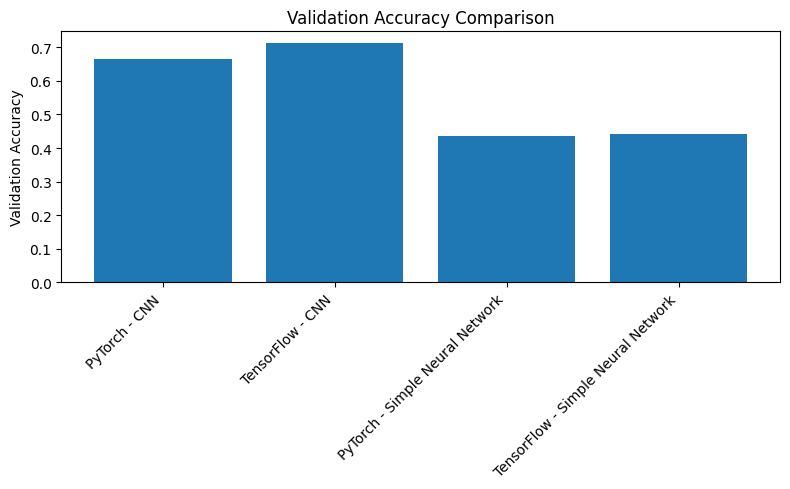

In [31]:
# Plotting the comparison charts
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Framework"] + " - " + comparison_df["Model"], comparison_df["Validation Accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.tight_layout()
plt.show()


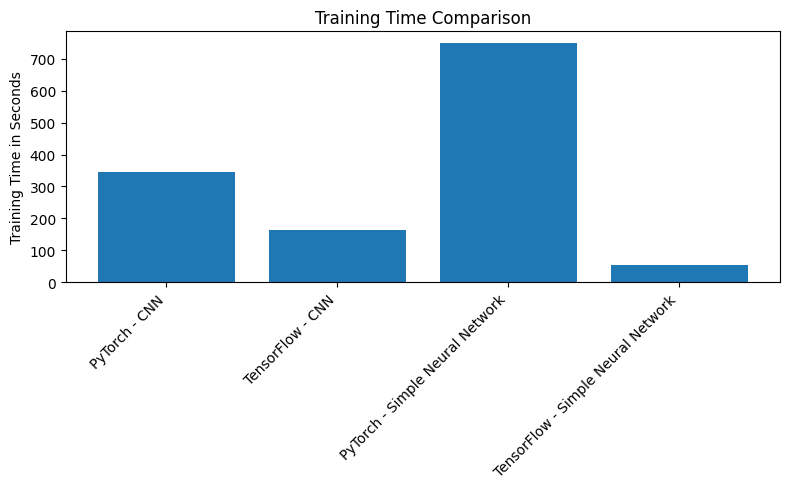

In [32]:
# Creating a chart for training time comparison
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Framework"] + " - " + comparison_df["Model"], comparison_df["Training Time Seconds"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Training Time in Seconds")
plt.title("Training Time Comparison")
plt.tight_layout()
plt.show()


## Discussion

The simple neural network is generally faster to train because it has fewer image-specific operations. However, it flattens the image into a vector, so it loses spatial relationships between nearby pixels.

The CNN is usually more accurate for CIFAR-10 because it learns spatial patterns such as edges, shapes, and textures through convolution and pooling layers. This makes it more suitable for image classification.

PyTorch gives more control over the training loop, which can help with debugging and understanding each training step. TensorFlow with Keras is more concise and easier to implement quickly because much of the training workflow is handled through `model.fit()`.

Training time may differ depending on whether your PC uses CPU or GPU, the available memory, and how efficiently each framework loads data.
